L_1=0.8369154703225539, L_2=1.15568189612967, L_3=-1.0050626166357435


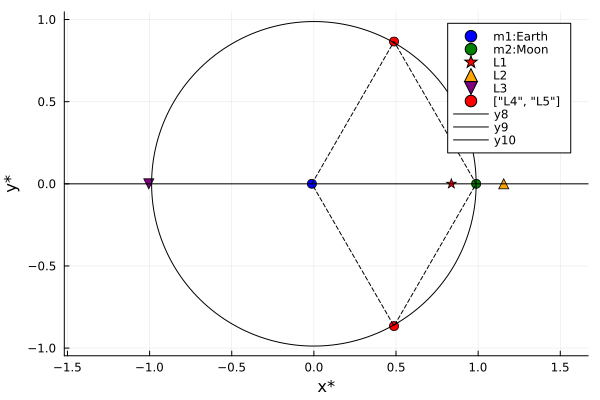

In [39]:
using Roots
using Plots

function lagrange_points_example()
    # These masses represent the Earth-Moon system
    m1 = 5.974E24  # kg
    m2 = 7.348E22  # kg
    pi2 = m2 / (m1 + m2)

    function collinear_lagrange(xstar)
        firstterm = xstar
        secondterm = (1 - pi2) ./ abs.(xstar + pi2).^3 .* (xstar + pi2)
        thirdterm = pi2 ./ abs.(xstar - 1 + pi2).^3 .* (xstar - 1 + pi2)
        y = firstterm - secondterm - thirdterm
    end
    
    L_2 = find_zero(collinear_lagrange, (1, 1.5), Bisection())
    L_1 = find_zero(collinear_lagrange, (0.01, 0.97), Bisection())
    L_3 = find_zero(collinear_lagrange, (-1, -1.5), Bisection())
    println("L_1=$L_1, L_2=$L_2, L_3=$L_3")
    
    function output()
        title!("The Lagrange Points in the Earth-Moon System")
        ylims!(-1.2, 1.2)
        xlims!(-1.2, 1.2)
        plot(aspect_ratio = :equal)
        xlabel!("x*")
        ylabel!("y*")
        scatter!([-pi2], [0], markersize = 5, color = :blue, label = "m1:Earth")
        scatter!([1 - pi2], [0], markersize = 5, color = :green, label = "m2:Moon")
        scatter!([L_1], [0], markershape = :star5, markersize = 5, color = :red, label = "L1")
        scatter!([L_2], [0], markershape = :utriangle, markersize = 5, color = :orange, label = "L2")
        scatter!([L_3], [0], markershape = :dtriangle, markersize = 5, color = :purple, label = "L3")
        scatter!([0.5 - pi2, 0.5 - pi2], [sqrt(3)/2, -sqrt(3)/2], markersize = 5, color = :red, label = ["L4", "L5"])
        plot!([-pi2, 0.5 - pi2, 1 - pi2, 0.5 - pi2, -pi2], [0, sqrt(3)/2, 0, -sqrt(3)/2, 0], linestyle = :dash, color = :black, label = "")
        hline!([0], color = :black)
        coords = range(0, stop = pi, length = 100)
        plot!((1 - pi2) .* cos.(coords), (1 - pi2) .* sin.(coords), color = :black)
        plot!((1 - pi2) .* cos.(coords), -(1 - pi2) .* sin.(coords), color = :black)
        plot!()
    end
    
    output()
end

lagrange_points_example()
